In [2]:
import re
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
import os
import json

**General parameters**
1 group of 1000 clients

percentage of successfull returns is 95% both

Plot functions

In [3]:
def plot_workunit_completion(ax, file_path, group_size, replica, label_prefix=''):
    try:
        df = pd.read_csv(file_path)
        df = df.iloc[1:].reset_index(drop=True)

        # 1. Основной график данных
        ax.plot(df['timestamp'], df['tasks_inprogress'], label=f'{label_prefix}Репликация = {replica}')
        
        # 2. Умная отрисовка порога
        threshold = group_size
        threshold_label = f'{label_prefix}Порог ({threshold})'
        
        # Проверяем, есть ли уже такая метка в легенде этого ax
        handles, labels = ax.get_legend_handles_labels()
        
        if threshold_label in labels:
            # Если метка уже есть, рисуем без нее (используя None или _nolegend_)
            ax.axhline(y=threshold, color='r', linestyle='--', label='_nolegend_')
        else:
            # Если метки еще нет (первый запуск), рисуем с ней
            ax.axhline(y=threshold, color='r', linestyle='--', label=threshold_label)

        # 3. Поиск точки пересечения
        intersection_point = df[df['tasks_inprogress'] <= threshold].head(1)

        if not intersection_point.empty:
            intersection_timestamp = intersection_point['timestamp'].iloc[0]
            intersection_value = intersection_point['tasks_inprogress'].iloc[0]
            
            ax.plot(intersection_timestamp, intersection_value, 'ro', markersize=8)
            ax.axvline(x=intersection_timestamp, color='g', linestyle='-.')

        # 4. Настройка внешнего вида
        ax.set_title('Незавершенные рабочие единицы со временем', fontsize=16)
        ax.set_xlabel('Время', fontsize=12)
        ax.set_ylabel('Рабочие единицы', fontsize=12)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        
        # Вызываем легенду, она сама подхватит только уникальные label
        ax.legend()

    except Exception as e:
        print(f"Ошибка при обработке {file_path}: {e}")

In [ ]:
STAT_PATH = "C:/Users/xmelo/AppData/LocalLow/DefaultCompany/_monobeh_boinc"
WORKUNITS_NAME = "workunits.csv"
PARAMS_NAME = "parameters.json"

**Experiment 1**

q = 2
r = 2-5



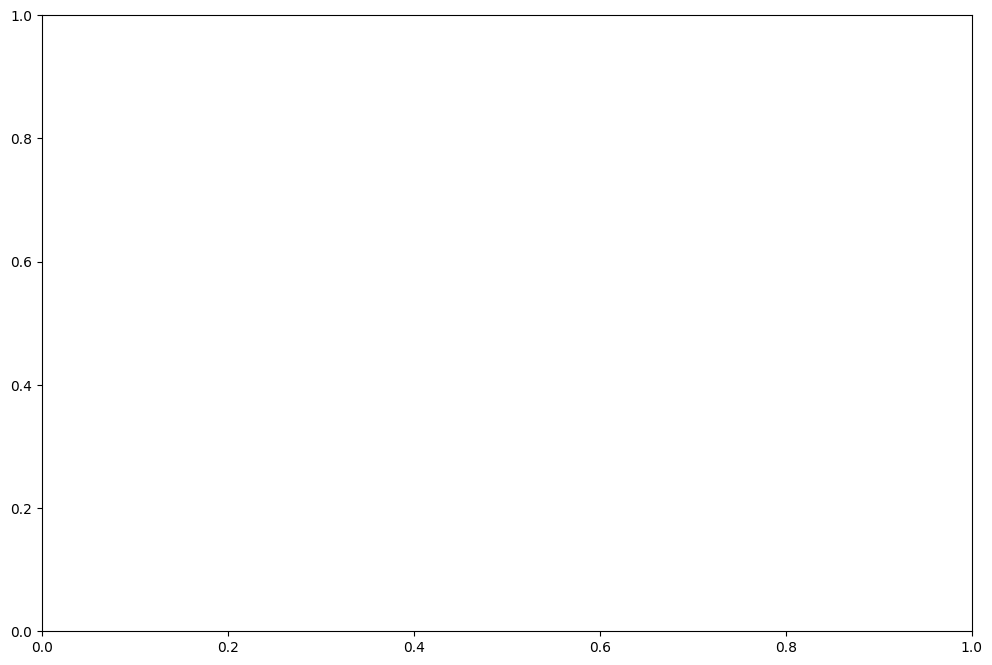

In [4]:
exp_name = "qandr"

folders = [f for f in os.listdir('.') 
           if os.path.isdir(f) and f.startswith(exp_name)]

params_data = dict()
workunits_paths = dict()

for ind, exp_folder in enumerate(folders):
    full_path = os.path.join('.', exp_folder)
    parameters_path = os.path.join(full_path, PARAMS_NAME)
    
    with open(parameters_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        params_data[ind] = data
    
    workunits_paths[ind] = os.path.join(full_path, WORKUNITS_NAME)

fig, ax = plt.subplots(figsize=(12, 8))

for ind, path in workunits_paths.items():
    group_size = params_data[ind]["GroupConfig"]["NumberOfClients"]
    replication_value = params_data[ind]["ProjectConfig"]["TaskConfig"]["InitialCreatedWorkunits"]
    plot_workunit_completion(ax, path, group_size=group_size, replica=replication_value)
